https://www.learnpytorch.io/08_pytorch_paper_replicating/

In [1]:
import os
import math
import torch
import numpy as np
import torchvision
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.19MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.77MB/s]


In [3]:
batch_size = 32
train_shuffle = True
test_shuffle = False
patch_size = 4
embed_dim = 128
in_channel = 1
eps = 1e-5
n_blocks = 10
n_classes = 10

In [4]:
train_prep = v2.Compose([
    # v2.RandomResizedCrop(size=(224, 224), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToTensor(),  
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, ), std=(0.229, )),
    v2.Grayscale()
])

test_prep = v2.Compose([
    v2.ToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, ), std=(0.229, )),
    v2.Grayscale()
])

def train_collate_fn(batch):
    images, labels = zip(*batch)
    prep_images = torch.stack([train_prep(i) for i in images])
    return prep_images, torch.tensor(labels, dtype=torch.long)

def test_collate_fn(batch):
    images, labels = zip(*batch)
    prep_images = torch.stack([test_prep(i) for i in images])
    return prep_images, torch.tensor(labels, dtype=torch.long)

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
train_dl = DataLoader(dataset=train_dataset, 
                      batch_size=batch_size, 
                      shuffle=train_shuffle, 
                      num_workers=os.cpu_count(),
                      collate_fn=train_collate_fn)

test_dl = DataLoader(dataset=test_dataset, 
                     batch_size=batch_size, 
                     shuffle=test_shuffle, 
                     num_workers=os.cpu_count(),
                     collate_fn=test_collate_fn)

In [6]:
# next(iter(train_dl))[0][0].shape

In [7]:
class PatchEmbedding(nn.Module):
    def __init__(self, patch_size, embed_dim, in_channel):
        super(PatchEmbedding, self).__init__()
        self.patch = nn.Conv2d(in_channels=in_channel, 
                               out_channels=embed_dim,
                               stride=patch_size,
                               kernel_size=patch_size)

    def forward(self, x):
        x = self.patch(x) # (batch_size, embed_dim, H/patch_size, W/patch_size)
        x = x.flatten(2).transpose(1, 2) # (batch_size, seq_length, embed_dim)
        return x # (batch_size, seq_length, embed_dim)

class LayerNorm(nn.Module):
    def __init__(self, embed_dim=embed_dim, eps=eps):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(embed_dim))
        self.bias = nn.Parameter(torch.zeros(embed_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True) # (1, 224, 1), if keepdim=False, (1, 224)
        var = x.var(dim=-1, keepdim=True, unbiased=False) # (1, 224, 1), if keepdim=False, (1, 224)
        return self.weight * (x - mean) / torch.sqrt(var+self.eps) + self.bias # (batch_size, seq_length, embed_dim)

class Gelu(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            math.sqrt(2 / math.pi) * (x + 0.044715 * x ** 3)
        ))

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim=embed_dim, num_head=8, bias=True, dropout_rate=0.0):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=bias)

        assert embed_dim % num_head == 0, "embed_dim % num_head != 0"

        self.d_k = embed_dim // num_head
        self.num_head = num_head
        self.dropout = nn.Dropout(dropout_rate)
        
        self.W_o = nn.Linear(embed_dim, embed_dim, bias=bias)
        
    def forward(self, x):
        batch_size, seq_length, embed_dim = x.size()
        q = self.W_q(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)
        k = self.W_k(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)
        v = self.W_v(x).view(batch_size, seq_length, self.num_head, self.d_k).transpose(1, 2)

        attention = self.dropout(F.softmax(q@k.transpose(-2, -1)/math.sqrt(self.d_k), dim=-1)) @ v # (batch_size, self.num_head, seq_length, self.d_k)
        out = self.W_o(attention.transpose(1, 2).contiguous().view(batch_size, seq_length, -1))
        
        return out # (batch_size, seq_length, embed_dim)

class MLP(nn.Module):
    def __init__(self, embed_dim=embed_dim):
        super().__init__()
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, 4*embed_dim),
            Gelu(),
            nn.Linear(4*embed_dim, embed_dim)
        )

    def forward(self, x):
        return self.ff(x)

class TransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layernorm_1 = LayerNorm()
        self.layernorm_2 = LayerNorm()
        self.mlp = MLP()
        self.mha = MultiHeadAttention()
        self.gelu = Gelu()

    def forward(self, x):
        shortcut = x
        x = self.layernorm_1(shortcut)
        x = self.mha(x)
        x = x + shortcut
        shortcut = x
        x = self.layernorm_2(x)
        x = self.mlp(x)
        x = x + shortcut
        return x

class ViT(nn.Module):
    def __init__(self, n_blocks=n_blocks,
                 n_classes=n_classes, 
                 patch_size=patch_size, 
                 embed_dim=embed_dim, 
                 in_channel=in_channel):
        super().__init__()
        self.mlp_head = nn.Sequential(
            LayerNorm(),
            nn.Linear(embed_dim, n_classes)
        )
        self.patch_embedding = PatchEmbedding(patch_size=patch_size,
                                              embed_dim=embed_dim, 
                                              in_channel=in_channel)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.block = nn.Sequential(*[TransformerEncoder() for i in range(n_blocks)])

    def forward(self, x):
        batch_size = x.size(0)
        patch_embed = self.patch_embedding(x)
        cls_token = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_token, patch_embed), dim=1)
        x = self.block(x)
        cls_output = x[:, 0]
        logits = self.mlp_head(cls_output)
        return logits

In [8]:
vit_model = ViT()

vit_model

ViT(
  (mlp_head): Sequential(
    (0): LayerNorm()
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
  (patch_embedding): PatchEmbedding(
    (patch): Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
  )
  (block): Sequential(
    (0): TransformerEncoder(
      (layernorm_1): LayerNorm()
      (layernorm_2): LayerNorm()
      (mlp): MLP(
        (ff): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): Gelu()
          (2): Linear(in_features=512, out_features=128, bias=True)
        )
      )
      (mha): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
      )
      (gelu): Gelu()
    )
    (1): TransformerEncoder(
      (layernorm_1): La

In [9]:
class Trainer:
    def __init__(self, 
                 optimizer,
                 model,
                 loss,
                 train_dl,
                 val_dl,
                 lr_scheduler,
                 patience,
                 device="cuda:0" if torch.cuda.is_available() else "cpu"):
        self.loss = loss
        self.device = device
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.lr_scheduler = lr_scheduler
        self.model = model.to(device)
        self.optimizer = optimizer
        self.patience = patience 
        self.best_val_loss = float("inf")
        self.counter = 0          

    def train(self, train_dl):
        total_loss = 0
        total_accuracy = 0
        
        self.model.train()
        for X, y in train_dl:
            X, y = X.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            logits = self.model(X) 
            loss = self.loss(logits, y)
            total_loss += loss.item()
            total_accuracy += accuracy_score(y.cpu().numpy(), 
                                             torch.argmax(logits, dim=1).cpu().numpy())
            loss.backward()
            self.optimizer.step()
            
        return total_loss / len(train_dl), total_accuracy / len(train_dl)

    def eval(self, val_dl):
        total_loss = 0
        total_accuracy = 0

        self.model.eval()

        with torch.no_grad():
            for X, y in val_dl:
                X, y = X.to(self.device), y.to(self.device)
                logits = self.model(X) 
                loss = self.loss(logits, y)
                total_loss += loss.item()
                total_accuracy += accuracy_score(y.cpu().numpy(), 
                                                 torch.argmax(logits, dim=1).cpu().numpy())
            
        return total_loss / len(val_dl), total_accuracy / len(val_dl)

    def fit(self, n_epochs):
        data = {"train_loss":[], "train_accuracy":[],
                "eval_loss":[], "eval_accuracy":[]}
        for epoch in range(n_epochs):
            train_loss, train_accuracy = self.train(self.train_dl)
            val_loss, val_accuracy = self.eval(self.val_dl)

            print(f"Epoch [{epoch+1}/{n_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

            self.lr_scheduler.step(val_loss)

            data["train_loss"].append(train_loss)
            data["train_accuracy"].append(train_accuracy)
            data["eval_loss"].append(val_loss)
            data["eval_accuracy"].append(val_accuracy)

            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.counter = 0
                torch.save(self.model.state_dict(), "best_vit.pth")
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    print(f"Early stopping triggered at epoch {epoch+1}")
                    break
                    
        return data

In [10]:
loss = torch.nn.CrossEntropyLoss()
optim = torch.optim.RMSprop(params=vit_model.parameters(), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer=optim, mode="min", factor=0.5, patience=2)

In [11]:
trainer = Trainer(model=vit_model, 
                  optimizer=optim, 
                  loss=loss, 
                  train_dl=train_dl,
                  val_dl=test_dl,
                  patience=5,
                  lr_scheduler=scheduler)

In [12]:
history = trainer.fit(n_epochs=100)

Epoch [1/50] Train Loss: 1.6504, Train Acc: 0.4016 | Val Loss: 1.3566, Val Acc: 0.5054
Epoch [2/50] Train Loss: 1.2716, Train Acc: 0.5453 | Val Loss: 1.2042, Val Acc: 0.5732
Epoch [3/50] Train Loss: 1.1243, Train Acc: 0.6030 | Val Loss: 1.1076, Val Acc: 0.6078
Epoch [4/50] Train Loss: 1.0199, Train Acc: 0.6401 | Val Loss: 1.0167, Val Acc: 0.6417
Epoch [5/50] Train Loss: 0.9455, Train Acc: 0.6680 | Val Loss: 0.9259, Val Acc: 0.6790
Epoch [6/50] Train Loss: 0.8876, Train Acc: 0.6888 | Val Loss: 0.8657, Val Acc: 0.6936
Epoch [7/50] Train Loss: 0.8395, Train Acc: 0.7078 | Val Loss: 0.7998, Val Acc: 0.7247
Epoch [8/50] Train Loss: 0.7989, Train Acc: 0.7234 | Val Loss: 0.7804, Val Acc: 0.7256
Epoch [9/50] Train Loss: 0.7627, Train Acc: 0.7357 | Val Loss: 0.7420, Val Acc: 0.7385
Epoch [10/50] Train Loss: 0.7330, Train Acc: 0.7438 | Val Loss: 0.7303, Val Acc: 0.7443
Epoch [11/50] Train Loss: 0.7043, Train Acc: 0.7553 | Val Loss: 0.7070, Val Acc: 0.7530
Epoch [12/50] Train Loss: 0.6773, Train A

In [13]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['eval_loss'], label='Validation Loss', marker='s')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Plot Accuracy
    axes[1].plot(history['train_accuracy'], label='Train Accuracy', marker='o')
    axes[1].plot(history['eval_accuracy'], label='Validation Accuracy', marker='s')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*50}")
    print(f"Final Training Results:")
    print(f"{'='*50}")
    print(f"Best Validation Loss: {min(history['eval_loss']):.4f}")
    print(f"Best Validation Accuracy: {max(history['eval_accuracy']):.4f}")
    print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
    print(f"Final Training Accuracy: {history['train_accuracy'][-1]:.4f}")
    print(f"{'='*50}\n")

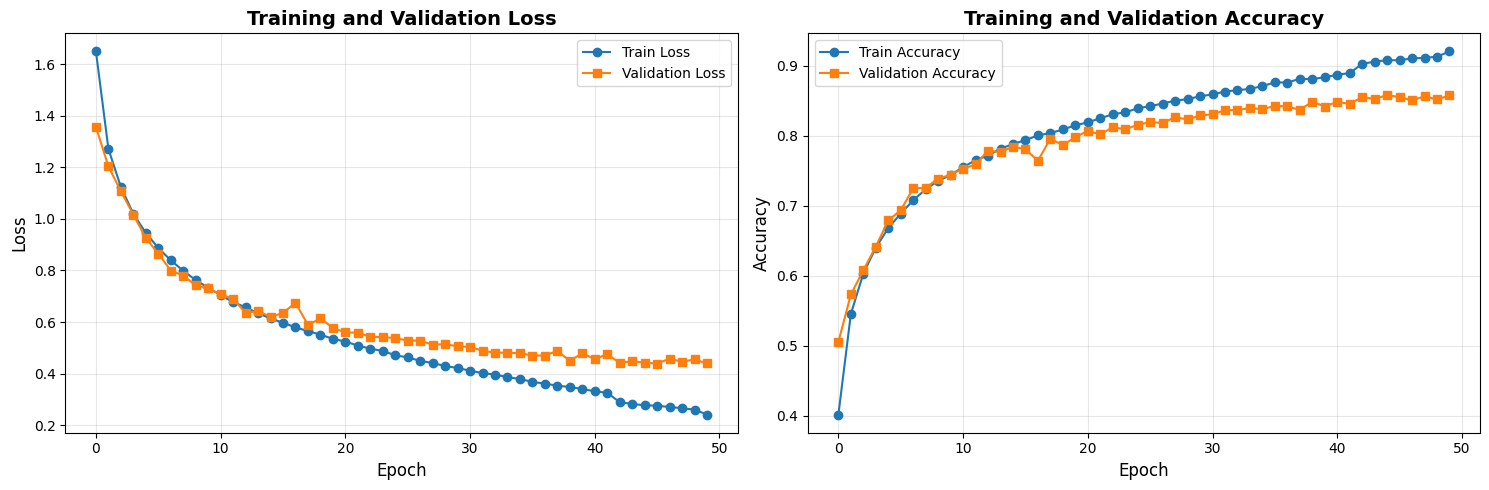


Final Training Results:
Best Validation Loss: 0.4385
Best Validation Accuracy: 0.8580
Final Training Loss: 0.2406
Final Training Accuracy: 0.9203



In [14]:
plot_training_history(history)

In [20]:
def predict_batch(model, test_dl, device, num_images=16):
    model.to(device)
    
    model.eval()
    
    # Get one batch
    images, labels = next(iter(test_dl))
    images = images.to(device)
    labels = labels.to(device)
    
    # Make predictions
    with torch.no_grad():
        logits = model(images)
        predictions = torch.argmax(logits, dim=1)
        probabilities = torch.softmax(logits, dim=1)
    
    # Move to CPU for plotting
    images = images.cpu()
    labels = labels.cpu()
    predictions = predictions.cpu()
    probabilities = probabilities.cpu()
    
    # Plot results
    num_images = min(num_images, len(images))
    rows = int(np.sqrt(num_images))
    cols = int(np.ceil(num_images / rows))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
    axes = axes.flatten() if num_images > 1 else [axes]
    
    for idx in range(num_images):
        ax = axes[idx]
        
        # Display image
        img = images[idx].squeeze()
        ax.imshow(img, cmap='gray')
        
        # Get prediction info
        pred = predictions[idx].item()
        true_label = labels[idx].item()
        confidence = probabilities[idx][pred].item()
        
        # Color code: green for correct, red for incorrect
        color = 'green' if pred == true_label else 'red'
        
        # Set title
        ax.set_title(f'True: {true_label}\nPred: {pred} ({confidence:.2%})',
                    color=color, fontsize=10, fontweight='bold')
        ax.axis('off')
    
    # Hide extra subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate accuracy for this batch
    correct = (predictions[:num_images] == labels[:num_images]).sum().item()
    accuracy = correct / num_images
    print(f"\nBatch Accuracy: {accuracy:.2%} ({correct}/{num_images} correct)")

In [21]:
vit_model_loaded = ViT()

vit_model_loaded.load_state_dict(torch.load("/kaggle/working/best_vit.pth",
                                            map_location="cuda:0" if torch.cuda.is_available() else "cpu"))

<All keys matched successfully>

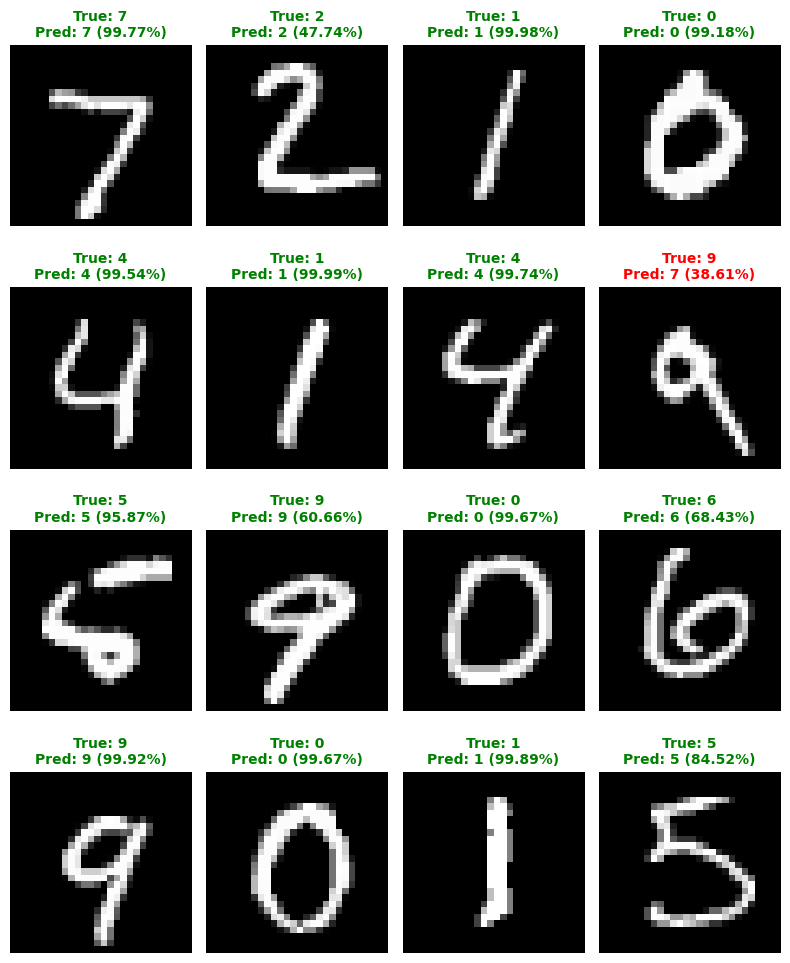


Batch Accuracy: 93.75% (15/16 correct)


In [22]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
predict_batch(vit_model_loaded, test_dl, device, num_images=16)